In [1]:
import _bootstrap  # noqa: F401

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import locale, matplotlib
locale.setlocale(locale.LC_ALL, 'ru_RU')
matplotlib.rcParams['axes.formatter.use_locale'] = True

t_net_filtering = np.array([4. * i for i in range(25)])

In [2]:
import pickle

from discretized_filter.paths import saved_path_dir

id1 = 'example_for_arc_v12_one_jump'
id2 = 'example_for_arc_v12_two_jumps'

with open(saved_path_dir(id1) / 'rmse_10000_paths/res_theta.pkl', 'rb') as f:
    res_theta1 = pickle.load(f)

with open(saved_path_dir(id1) / 'rmse_10000_paths/res_y.pkl', 'rb') as f:
    res_y1 = pickle.load(f)

with open(saved_path_dir(id2) / 'rmse_10000_paths/res_theta.pkl', 'rb') as f:
    res_theta2 = pickle.load(f)

with open(saved_path_dir(id2) / 'rmse_10000_paths/res_y.pkl', 'rb') as f:
    res_y2 = pickle.load(f)

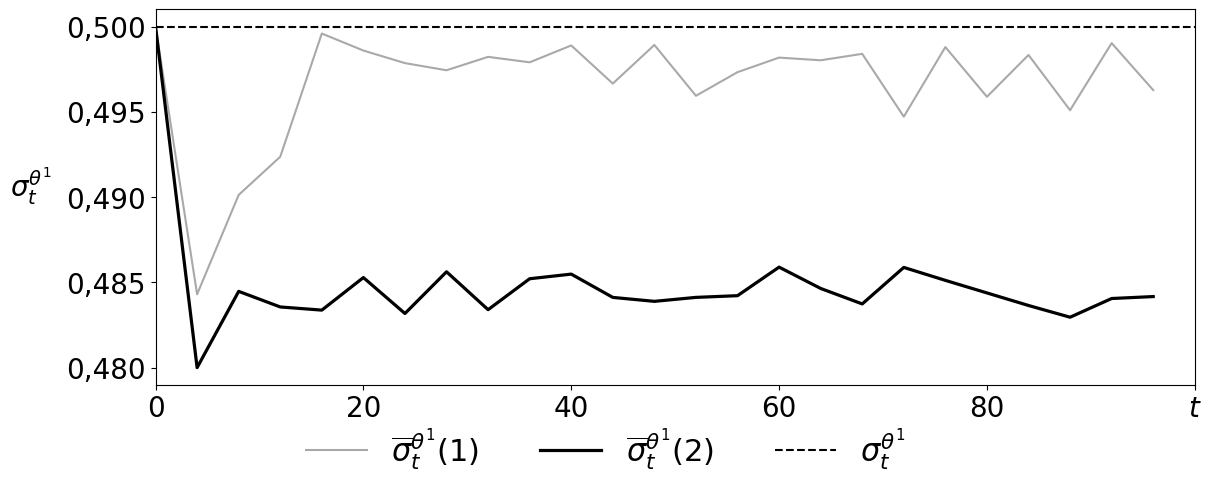

In [6]:
fig, ax = plt.subplots( figsize=(12, 5), layout='constrained')

ax.plot(t_net_filtering, np.sqrt(res_theta1[:, 0]), 
        color='darkgray',
        label='$\\overline{\\sigma}_t^{\\theta^1}(1)$',
)
ax.plot(t_net_filtering, np.sqrt(res_theta2[:, 0]), 
        color='k',
        label='$\\overline{\\sigma}_t^{\\theta^1}(2)$', 
        lw=2.3
)
# ax.plot(t_net_filtering, np.sqrt(res_theta3[:, 0]), 
#         color='blue',
#         label='$\\hat{\\sigma}^{\\theta}(1), n = 10$',
# )
# ax.plot(t_net_filtering, np.sqrt(res_theta4[:, 0]), 
#         color='darkgreen',
#         label='$\\hat{\\sigma}^{\\theta}(2), n = 10$', 
#         lw=2.3
# )
ax.axhline(0.5, ls='--', color='k', label='$\\sigma_t^{\\theta^1}$')

ax.set_ylabel('$\\sigma_t^{\\theta^1}$', rotation='horizontal', fontsize=20)
ax.set_xlim(t_net_filtering[0], t_net_filtering[-1])
ax.set_xticks(
    ticks=list(range(0, 101, 20)), 
    labels=['0', '20', '40', '60', '80', '$t$'],
)
ax.tick_params(labelsize=20)
ax.yaxis.set_label_coords(-0.12, 0.475)

#ax.set_yscale('log')

fig.legend(
    loc='outside lower center',
    ncols=5,
    fontsize=22,
    frameon=False
)
plt.locator_params(axis='y', nbins=5) 

fig.savefig('rmse_theta.png', dpi=200, bbox_inches='tight')

plt.show()

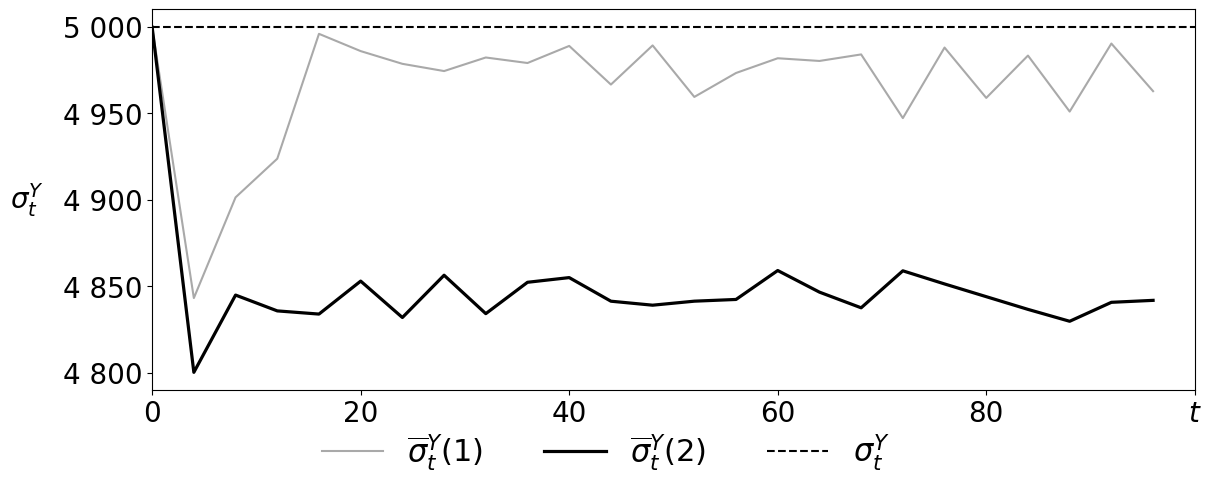

In [8]:
fig, ax = plt.subplots(1, figsize=(12, 5), layout='constrained')

ax.plot(t_net_filtering, np.sqrt(res_y1[:, 0]), color='darkgray', label='$\\overline{\\sigma}_t^{Y}(1)$',)
ax.plot(t_net_filtering, np.sqrt(res_y2[:, 0]), color='k', label='$\\overline{\\sigma}_t^{Y}(2)$', lw=2.3)
# ax.plot(t_net_filtering, np.sqrt(res_y3[:, 0]), color='blue', label='$\\hat{\\sigma}^Y(1), n = 10$',)
# ax.plot(t_net_filtering, np.sqrt(res_y4[:, 0]), color='darkgreen', label='$\\hat{\\sigma}^Y(2), n = 10$', lw=2.3)
ax.axhline(5000, color='k', ls='--', label='$\\sigma_t^{Y}$',)

ax.set_ylabel('$\\sigma_t^{Y}$', rotation='horizontal', fontsize=20)
ax.set_xlim(t_net_filtering[0], t_net_filtering[-1])
ax.set_xticks(
    ticks=list(range(0, 101, 20)), 
    labels=['0', '20', '40', '60', '80', '$t$'],
    fontsize=20,
)
ax.yaxis.set_label_coords(-0.12, 0.45)
ax.tick_params(labelsize=20)
#ax.set_yscale('log')
fig.legend(
    loc='outside lower center',
    ncols=5,
    fontsize=22,
    frameon=False
)
plt.locator_params(axis='y', nbins=5) 

fig.savefig('rmse_y.png', dpi=200, bbox_inches='tight')

plt.show()